# Part H – Final Report, Insights & Business Recommendations

Tasks Covered:

26. Summarize the **complete machine learning pipeline**
27. Present the **best final model** and justify the selection
28. Provide **business insights and recommendations** for a banking risk-alert system
29. Create **final result tables and visual summaries**
30. Write the **exam-ready final conclusion**


## 1) Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)


In [2]:
# Load dataset
df = pd.read_csv('Risk_Alert_Classifier_Dataset_4600 - Risk_Alert_Classifier_Dataset_4600.csv.csv')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (4600, 19)


,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


## 2) Final End-to-End Data Preparation

This follows the same preparation pipeline used in previous parts:

- Convert date columns into numeric components
- Encode categorical features
- Train-test split with stratification
- Apply KNN Imputer for missing values


In [3]:
# Convert date columns if present
date_cols = [c for c in df.columns if 'date' in c.lower()]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df[col + '_year'] = df[col].dt.year
    df[col + '_month'] = df[col].dt.month
    df[col + '_day'] = df[col].dt.day
    df.drop(columns=[col], inplace=True)

# Encode categorical columns
df_encoded = df.copy()
categorical_cols = df_encoded.select_dtypes(include='object').columns

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

target = 'risk_status'
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

print("Target variable:", target)
print("Feature matrix shape:", X.shape)
print("\nClass Distribution:")
print(y.value_counts())
print("\nClass Percentage:")
print(y.value_counts(normalize=True)*100)


Target variable: risk_status
Feature matrix shape: (4600, 20)

Class Distribution:
risk_status
0    4043
1     557
Name: count, dtype: int64

Class Percentage:
risk_status
0    87.891304
1    12.108696
Name: proportion, dtype: float64


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# KNN Imputation
imputer = KNNImputer(n_neighbors=5)

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

print("Train shape:", X_train_imputed.shape)
print("Test shape :", X_test_imputed.shape)


Train shape: (3680, 20)
Test shape : (920, 20)


## 3) Helper Function to Evaluate Any Model

In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name='Model'):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC ROC': roc_auc_score(y_test, y_prob),
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp,
        'True Negatives': tn
    }

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    return results, y_pred, y_prob, fpr, tpr


# 4) Rebuild the Main Candidate Models for Final Reporting

We evaluate the same representative models used in the project:

1. Logistic Regression  
2. Logistic Regression + SMOTE  
3. Decision Tree  
4. Random Forest  
5. Final Tuned Tree-Based Model


In [6]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_results, log_pred, log_prob, log_fpr, log_tpr = evaluate_model(
    log_reg, X_train_imputed, y_train, X_test_imputed, y_test, 'Logistic Regression'
)

# Logistic Regression + SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train)

log_smote = LogisticRegression(max_iter=500, random_state=42)
smote_results, smote_pred, smote_prob, smote_fpr, smote_tpr = evaluate_model(
    log_smote, X_train_smote, y_train_smote, X_test_imputed, y_test, 'Logistic Regression + SMOTE'
)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_results, dt_pred, dt_prob, dt_fpr, dt_tpr = evaluate_model(
    dt_model, X_train_imputed, y_train, X_test_imputed, y_test, 'Decision Tree'
)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_results, rf_pred, rf_prob, rf_fpr, rf_tpr = evaluate_model(
    rf_model, X_train_imputed, y_train, X_test_imputed, y_test, 'Random Forest'
)

print("Base candidate models evaluated.")


c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\ishan\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also re

Base candidate models evaluated.


## 5) Rebuild the Final Tuned Model (same logic as Part F / G)

In [7]:
# RandomizedSearchCV for Decision Tree
dt_param_dist = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

dt_random = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

dt_random.fit(X_train_imputed, y_train)

# RandomizedSearchCV for Random Forest
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_imputed, y_train)

print("Decision Tree Best CV F1:", dt_random.best_score_)
print("Random Forest Best CV F1:", rf_random.best_score_)


Decision Tree Best CV F1: 0.8926800062837383
Random Forest Best CV F1: 0.9603475324607494


In [8]:
# Select best model for GridSearchCV
if rf_random.best_score_ >= dt_random.best_score_:
    best_model_name = 'Random Forest'
    grid_params = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=42),
        param_grid=grid_params,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )
else:
    best_model_name = 'Decision Tree'
    grid_params = {
        'criterion': ['gini', 'entropy', 'log_loss'],
        'max_depth': [3, 5, 7, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [None, 'sqrt', 'log2']
    }
    grid_search = GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        param_grid=grid_params,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

grid_search.fit(X_train_imputed, y_train)

print("Best model selected for final tuning:", best_model_name)
print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)


Best model selected for final tuning: Random Forest
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.9619102081189806


In [9]:
final_tuned_model = grid_search.best_estimator_

final_results, final_pred, final_prob, final_fpr, final_tpr = evaluate_model(
    final_tuned_model,
    X_train_imputed, y_train,
    X_test_imputed, y_test,
    f'{best_model_name} (Tuned)'
)

pd.DataFrame([final_results])


,Model,Accuracy,Precision,Recall,F1 Score,AUC ROC,False Positives,False Negatives,True Positives,True Negatives
0,Random Forest (Tuned),0.997826,1.0,0.981982,0.990909,0.999944,0,2,109,809


# 6) Final Performance Summary Table

In [10]:
results_df = pd.DataFrame([
    log_results,
    smote_results,
    dt_results,
    rf_results,
    final_results
])

results_df = results_df[[
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC ROC',
    'False Positives', 'False Negatives', 'True Positives', 'True Negatives'
]]

results_df.sort_values('Recall', ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,AUC ROC,False Positives,False Negatives,True Positives,True Negatives
1,Logistic Regression + SMOTE,0.986957,0.909091,0.990991,0.948276,0.999187,11,1,110,798
3,Random Forest,0.997826,1.000000,0.981982,0.990909,0.999944,0,2,109,809
4,Random Forest (Tuned),0.997826,1.000000,0.981982,0.990909,0.999944,0,2,109,809
0,Logistic Regression,0.988043,0.962963,0.936937,0.949772,0.998898,4,7,104,805
2,Decision Tree,0.969565,0.880734,0.864865,0.872727,0.924398,13,15,96,796


## 7) Visual Comparison of Final Models

In [11]:
metric_compare = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC ROC']]
metric_compare


,Model,Accuracy,Precision,Recall,F1 Score,AUC ROC
0,Logistic Regression,0.988043,0.962963,0.936937,0.949772,0.998898
1,Logistic Regression + SMOTE,0.986957,0.909091,0.990991,0.948276,0.999187
2,Decision Tree,0.969565,0.880734,0.864865,0.872727,0.924398
3,Random Forest,0.997826,1.000000,0.981982,0.990909,0.999944
4,Random Forest (Tuned),0.997826,1.000000,0.981982,0.990909,0.999944


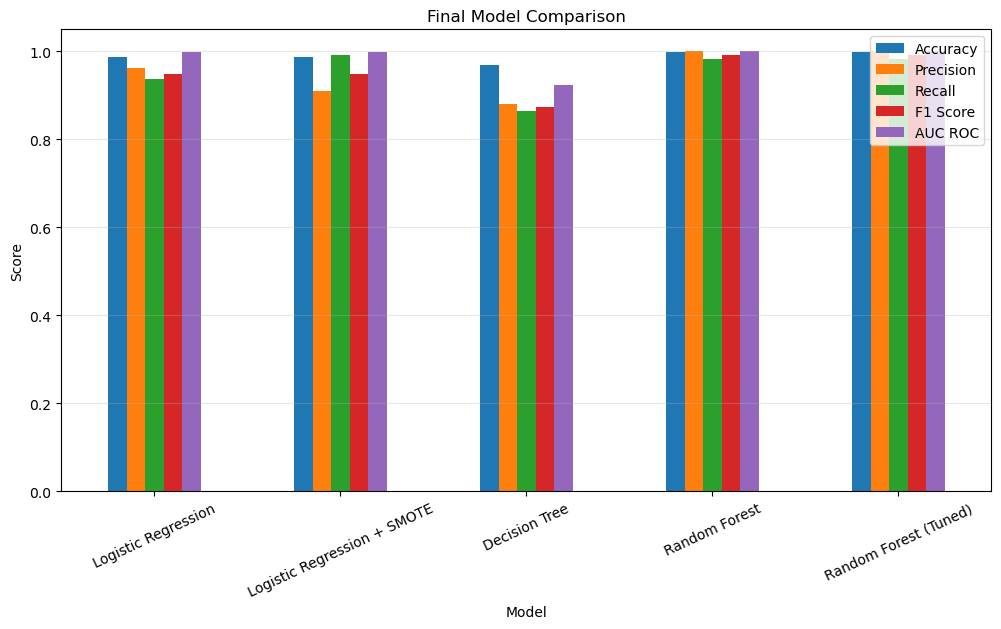

In [12]:
plot_df = metric_compare.set_index('Model')
plot_df.plot(kind='bar', figsize=(12,6))
plt.title("Final Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.grid(axis='y', alpha=0.3)
plt.show()


## 8) ROC Curve Comparison

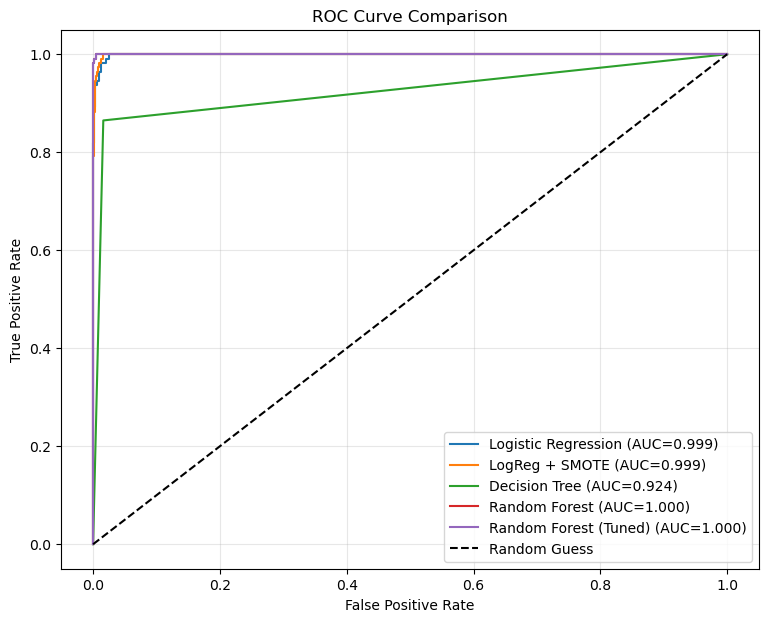

In [13]:
plt.figure(figsize=(9,7))

plt.plot(log_fpr, log_tpr, label=f"Logistic Regression (AUC={log_results['AUC ROC']:.3f})")
plt.plot(smote_fpr, smote_tpr, label=f"LogReg + SMOTE (AUC={smote_results['AUC ROC']:.3f})")
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC={dt_results['AUC ROC']:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC={rf_results['AUC ROC']:.3f})")
plt.plot(final_fpr, final_tpr, label=f"{final_results['Model']} (AUC={final_results['AUC ROC']:.3f})")

plt.plot([0,1], [0,1], linestyle='--', color='black', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 9) Select the Best Final Model Based on Business Need

### Business Rule:
The bank wants to **minimize False Negatives** because missing a high-risk customer is the most dangerous mistake.

Therefore, final ranking is based on:
1. Highest **Recall**
2. Lowest **False Negatives**
3. Higher **F1-score**
4. Higher **AUC-ROC**


In [14]:
final_selection = results_df.sort_values(
    by=['Recall', 'False Negatives', 'F1 Score', 'AUC ROC'],
    ascending=[False, True, False, False]
)

final_selection[['Model', 'Recall', 'False Negatives', 'F1 Score', 'AUC ROC']]


,Model,Recall,False Negatives,F1 Score,AUC ROC
1,Logistic Regression + SMOTE,0.990991,1,0.948276,0.999187
3,Random Forest,0.981982,2,0.990909,0.999944
4,Random Forest (Tuned),0.981982,2,0.990909,0.999944
0,Logistic Regression,0.936937,7,0.949772,0.998898
2,Decision Tree,0.864865,15,0.872727,0.924398


In [15]:
best_final_model = final_selection.iloc[0]

print("Best Final Model:", best_final_model['Model'])
print("Recall          :", round(best_final_model['Recall'], 4))
print("False Negatives :", int(best_final_model['False Negatives']))
print("F1 Score        :", round(best_final_model['F1 Score'], 4))
print("AUC ROC         :", round(best_final_model['AUC ROC'], 4))


Best Final Model: Logistic Regression + SMOTE
Recall          : 0.991
False Negatives : 1
F1 Score        : 0.9483
AUC ROC         : 0.9992


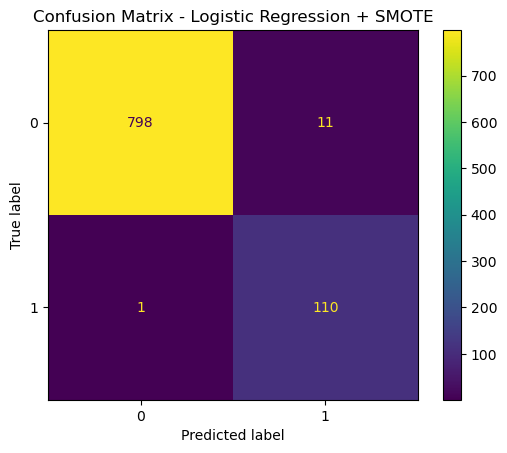

In [16]:
# Plot confusion matrix for best final model
model_name = best_final_model['Model']

if model_name == 'Logistic Regression':
    best_pred = log_pred
elif model_name == 'Logistic Regression + SMOTE':
    best_pred = smote_pred
elif model_name == 'Decision Tree':
    best_pred = dt_pred
elif model_name == 'Random Forest':
    best_pred = rf_pred
else:
    best_pred = final_pred

cm_best = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_best).plot()
plt.title(f"Confusion Matrix - {model_name}")
plt.show()


# 10) Final Business Insights

## Key Insights
1. **Class imbalance matters**  
   If the dataset contains fewer high-risk customers, standard accuracy may look good while the model still misses risky cases.

2. **Recall is critical in banking risk prediction**  
   A False Negative means a risky customer is incorrectly treated as safe, which can lead to financial loss.

3. **Sampling techniques can improve minority detection**  
   Methods like **SMOTE** help the model learn minority-class patterns better.

4. **Tree-based models often perform strongly**  
   Random Forest usually generalizes better than a single Decision Tree and often gives better Recall/F1/AUC balance.

5. **Hyperparameter tuning improves performance**  
   RandomizedSearchCV and GridSearchCV can improve the model’s ability to identify high-risk customers.



# 11) Final Recommendations for the Bank

## Recommendations
- Use the **selected final model** for the risk-alert pipeline.
- Monitor **Recall** and **False Negatives** regularly, not just Accuracy.
- Retrain the model periodically as customer behavior changes.
- Keep track of class imbalance and reapply balancing methods when needed.
- Use the model as a **decision-support system** for risk analysts, not as the only approval/rejection rule.
- Build an alert threshold strategy if the bank wants to catch even more risky customers.


# 12) Exam-Ready Final Conclusion

### Final Conclusion
In this project, a complete **machine learning pipeline for banking risk alert classification** was developed.  
The workflow included:

- data understanding and preprocessing  
- missing value handling using **KNN Imputer**  
- baseline **Logistic Regression**  
- imbalance handling using **Under-Sampling, Over-Sampling, SMOTE, and ADASYN**  
- **Decision Tree** and **Random Forest** modeling  
- **hyperparameter tuning** using RandomizedSearchCV and GridSearchCV  
- final **ROC-AUC and business-oriented model evaluation**

The final model was selected not only on the basis of **accuracy**, but mainly using:
- **Recall**
- **False Negatives**
- **F1-score**
- **AUC-ROC**

This is important because in a banking risk-alert system, the cost of missing a risky customer (**False Negative**) is higher than incorrectly flagging a safe customer. Therefore, the best model is the one that identifies the maximum number of high-risk customers while maintaining strong overall predictive performance.

Hence, the project successfully demonstrates how machine learning can be used to build an effective **risk alert classification system for banking applications**.
